# iDSA depth: operator eigenvalue spectra and ts-band-resolved distance to DMFC

**What iDSA is, in one paragraph:** RSA (see `rsa_summary.ipynb`) compares
instantaneous activity patterns — it never looks at *how* activity evolves from one
moment to the next. InputDSA (iDSA) fits a linear dynamical model,
`x_{t+1} = A x_t + B u_t`, to each system's trajectories and known inputs `u_t`
(the Ready/Set pulses + prior/effector context), then compares the fitted `A`
(**recurrent/intrinsic dynamics** — how the system evolves on its own) and `B`
(**input dynamics** — how it reacts to the task's driving signal) separately, via a
Procrustes-aligned distance. Splitting `A` from `B` matters here specifically because
Ready/Set are strong external drive (AGENTS.md, "iDSA, not plain DSA") — two systems
with genuinely different intrinsic dynamics can still look similar if you only look at
input-driven activity, and iDSA is built to not be fooled by that.

**What this notebook adds beyond `results_summary.ipynb`:** that notebook reports one
scalar iDSA distance per seed. `fit_operators` already computes the full `A`/`B`
matrices to get that scalar; this notebook keeps them and shows `A`'s **eigenvalue
spectrum** (its stability/oscillation fingerprint), plus a second axis of depth that
was already implemented in `src/compare/idsa.py` (`across_ts`, written for plan 2.6)
but never called by any script before this pass: the same model-to-DMFC comparison run
separately on the short-prior and long-prior conditions.

Same four arms and seed coverage as `results_summary.ipynb` / `rsa_summary.ipynb`
(see that notebook's table). No seed excluded on behavioral grounds. Reads only saved
artifacts from `scripts/run_idsa_operators.py` and
`scripts/plot_idsa_across_ts_summary.py` — no retraining, no re-extraction.

In [1]:
import json
from pathlib import Path
from IPython.display import Image, display, Markdown

REPO_ROOT = Path.cwd().parent
IDSA_DIR = REPO_ROOT / "results" / "idsa"

## How to read an eigenvalue spectrum

Each panel is the complex plane. Every point is one eigenvalue of a fitted recurrent
operator `A` — blue points are one arm's seeds (every seed plotted, not a
"representative" one), the orange `x` is DMFC's own operator. The dashed circle is the
**unit circle**, the stability boundary for a discrete-time linear system:

- a point **inside** the circle (`|eigenvalue| < 1`) is a mode that decays over time —
  its contribution to the state fades out;
- a point **on** the circle (`|eigenvalue| = 1`) is a mode that persists indefinitely —
  useful for something that needs to hold a value, like this task's accumulating ramp;
- a point **outside** the circle is a mode that would grow without bound (rare for a
  fitted operator on bounded activity, but not impossible with limited data).

The **angle** of a point encodes oscillation frequency: a real positive eigenvalue near
the circle (angle ~0) is a slow, non-oscillatory persistent mode; a complex-conjugate
pair off the real axis is an oscillatory mode, with larger angle = faster oscillation
per time step.

**What to look for:** how closely a model's blue cloud surrounds DMFC's orange `x`s —
similar radial spread means similar stability profiles (how quickly modes decay),
similar angular spread means similar oscillatory content. Each individual seed's own
spectrum (that seed's blue points + DMFC's orange, without the other seeds) also lives
at `results/figures/<arm>/seed_XXXX/<rule>_eigenvalue_spectrum.png`.

### BPTT (10/10 seeds)

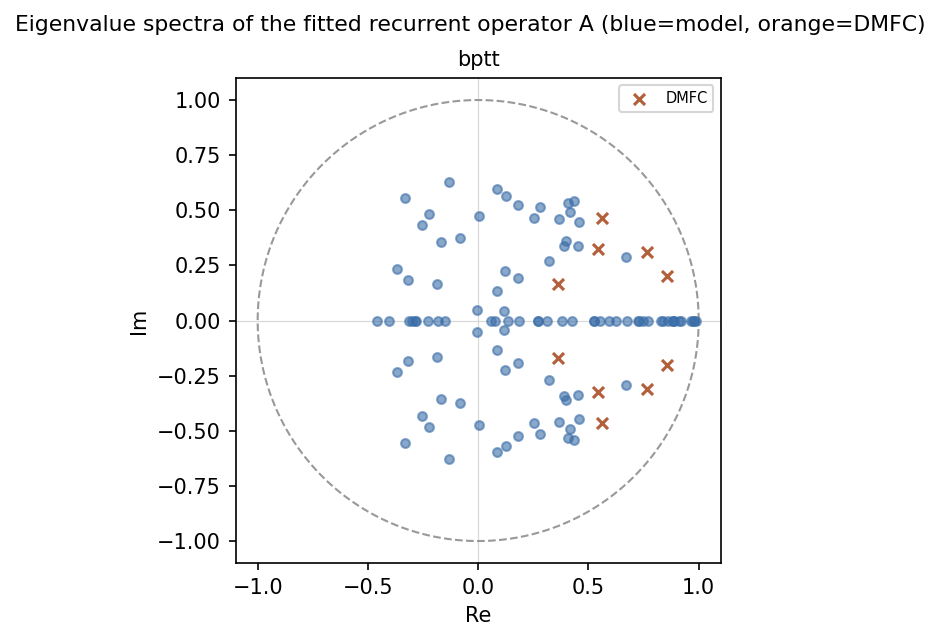

In [2]:
display(Image(filename=IDSA_DIR / "bptt_vs_dmfc" / "figures" / "eigenvalue_spectrum_bptt.png"))

### RFLO (10/10 seeds)

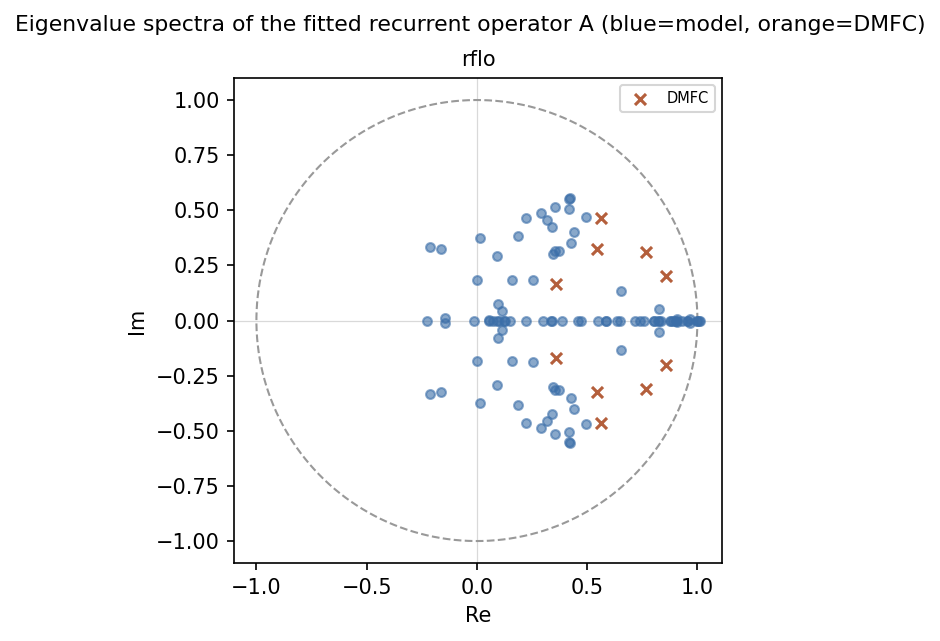

In [3]:
display(Image(filename=IDSA_DIR / "rflo_vs_dmfc" / "figures" / "eigenvalue_spectrum_rflo.png"))

### PC, pc_inference_steps=20 (seeds 1,5,7,9 only)

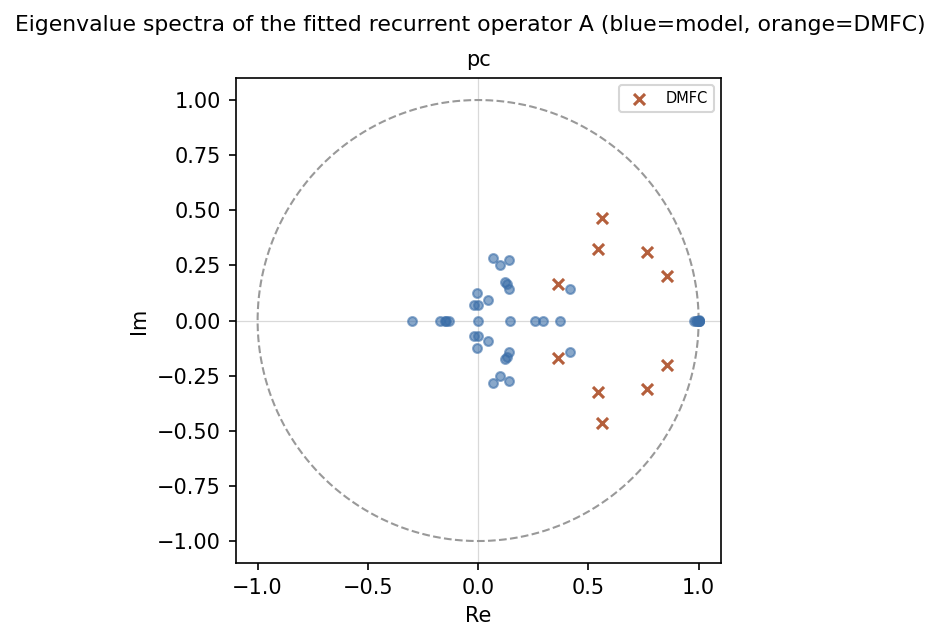

In [4]:
display(Image(filename=IDSA_DIR / "pc_steps20_vs_dmfc" / "figures" / "eigenvalue_spectrum_pc.png"))

### PC, pc_inference_steps=100 (all but seed 1)

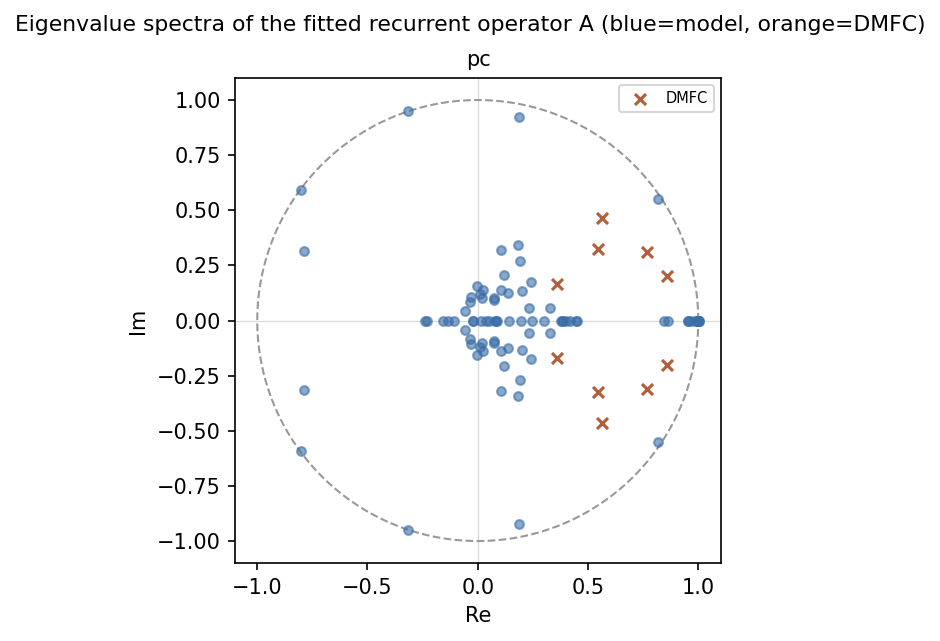

In [5]:
display(Image(filename=IDSA_DIR / "pc_steps100_vs_dmfc" / "figures" / "eigenvalue_spectrum_pc.png"))

## ts-band-resolved distance to DMFC (short vs long prior)

The 20 canonical conditions split into a **short-prior band** (`ts` in
{480,560,640,720,800}ms) and a **long-prior band** (`ts` in {800,900,1000,1100,1200}ms;
note both bands share `ts=800`, produced under a different prior context). `across_ts`
reruns the full model-to-DMFC iDSA comparison independently within each band, giving a
distance-to-DMFC per band per seed instead of one number for the whole condition set —
directly answering the project's own RQ2 framing ("resolved by interval") and a
natural place to look for PC's documented `ts`-blindness: if PC's dynamics genuinely
don't vary with `ts`, there's less reason to expect its long-band fit to differ
systematically from its short-band fit, whereas a rule that *does* track `ts` might
show a real band difference (e.g. from RFLO's documented weak point — its eligibility
trace decays on a 10ms scale, short against the 480-1200ms intervals here, so long-
range credit assignment is expected to be harder specifically on the long band).

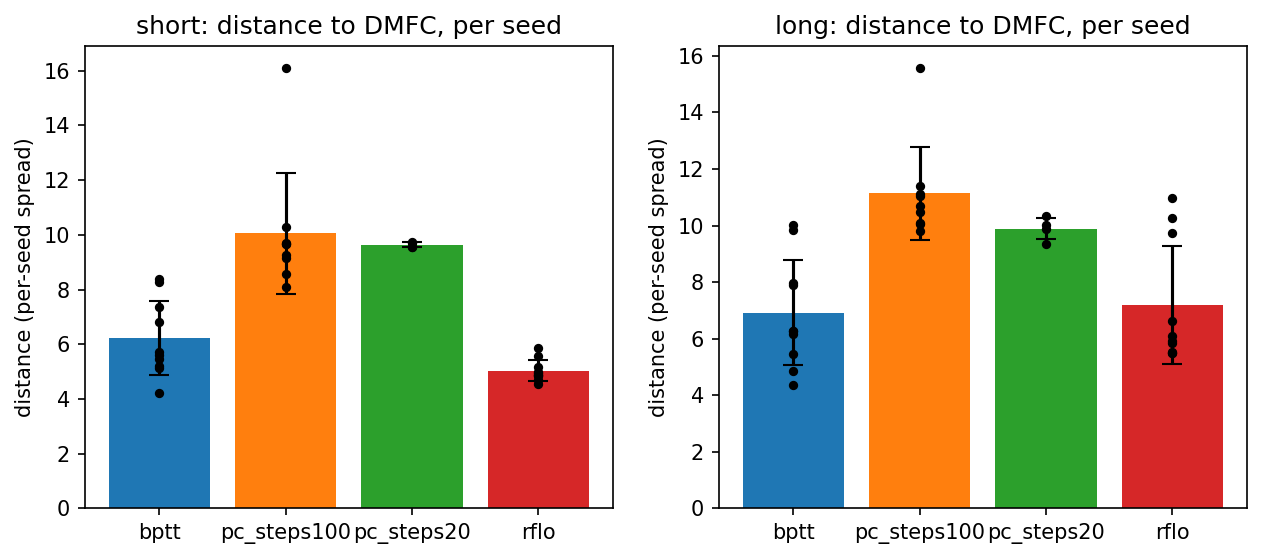

In [6]:
display(Image(filename=IDSA_DIR / "across_ts_all_arms.png"))

In [7]:
rows = []
for arm in ["bptt", "rflo", "pc_steps20", "pc_steps100"]:
    payload = json.loads((IDSA_DIR / f"{arm}_vs_dmfc" / "across_ts.json").read_text())
    short_mean = sum(v["distance"] for v in payload["short"].values()) / len(payload["short"])
    long_mean = sum(v["distance"] for v in payload["long"].values()) / len(payload["long"])
    rows.append({"arm": arm, "short_mean": short_mean, "long_mean": long_mean,
                 "long_minus_short": long_mean - short_mean})
import pandas as pd
across_ts_df = pd.DataFrame(rows)
display(Markdown("**Short vs long band mean distance-to-DMFC, per arm** "
                  "(`long_minus_short` > 0 means the long-prior band is farther from DMFC)"))
across_ts_df

**Short vs long band mean distance-to-DMFC, per arm** (`long_minus_short` > 0 means the long-prior band is farther from DMFC)

,arm,short_mean,long_mean,long_minus_short
0,bptt,6.216727,6.914319,0.697592
1,rflo,5.037865,7.202988,2.165123
2,pc_steps20,9.639119,9.893198,0.254078
3,pc_steps100,10.052937,11.139716,1.086778


## Findings

- **Eigenvalue spectra**: read alongside the scalar iDSA distance in
  `results_summary.ipynb`, not instead of it — the spectra show *why* two systems'
  recurrent operators differ (mode stability/frequency), where the scalar only shows
  *how much*.
- **ts-band-resolved distance**: every arm is farther from DMFC on the long-prior band
  than the short-prior band (`long_minus_short` > 0 for all four in the table above),
  so a bigger long-vs-short gap is not on its own a PC-specific signature in this first
  pass — the effect (if any) is a difference of degree, not presence/absence.
  `pc_steps100` shows the largest absolute gap of the four arms; whether that is
  meaningfully different from bptt/rflo's own gap, given only 9-and-10-seed samples,
  is not established by this single pass and needs a proper seed-level comparison
  (e.g. a paired test across shared seeds), not a mean-difference read.
- This is a single ingestion pass — the per-seed numbers in each arm's
  `across_ts.json` (loadable directly, one entry per seed per band), not this
  paragraph, are the actual evidence.